In [1]:
import pandas as pd
df_csv = pd.read_csv("peak demand.csv")
import warnings
warnings.filterwarnings("ignore")

In [2]:
nulls_per_col = df_csv.isnull().sum()
total_nulls = nulls_per_col.sum()

print("Nulls per column:\n", nulls_per_col)
print("\nTotal null values:", total_nulls)

# show rows that contain any nulls (if any)
if total_nulls:
    display(df_csv[df_csv.isnull().any(axis=1)])
else:
    print("No rows contain null values.")

Nulls per column:
 Date            0
Morning_Peak    0
Day_Peak        0
Evening_Peak    0
dtype: int64

Total null values: 0
No rows contain null values.


In [3]:
df_csv.describe
df_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539 entries, 0 to 538
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          539 non-null    object
 1   Morning_Peak  539 non-null    int64 
 2   Day_Peak      539 non-null    int64 
 3   Evening_Peak  539 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 17.0+ KB


In [4]:
# parse Date column to datetime (day-first format)
df_csv['Date'] = pd.to_datetime(df_csv['Date'], format='%d-%m-%Y', dayfirst=True, errors='coerce')

# report any parse issues
if df_csv['Date'].isnull().any():
    print("Warning: some dates could not be parsed:")
    display(df_csv[df_csv['Date'].isnull()])
else:
    print("All dates parsed successfully.")

# create separate DataFrames containing Date and the respective peak column
df_morning = df_csv[['Date', 'Morning_Peak']].copy()
df_day = df_csv[['Date', 'Day_Peak']].copy()
df_evening = df_csv[['Date', 'Evening_Peak']].copy()

# display previews
display(df_morning.head())
display(df_day.head())
display(df_evening.head())

All dates parsed successfully.


,Date,Morning_Peak
0,2024-04-01,21680
1,2024-04-02,22209
2,2024-04-03,22683
3,2024-04-04,22906
4,2024-04-05,22949


,Date,Day_Peak
0,2024-04-01,22516
1,2024-04-02,23030
2,2024-04-03,23504
3,2024-04-04,23520
4,2024-04-05,23134


,Date,Evening_Peak
0,2024-04-01,21708
1,2024-04-02,22304
2,2024-04-03,22730
3,2024-04-04,22480
4,2024-04-05,22491


In [5]:
# check for duplicate Date timestamps in each DataFrame
datasets = {
    'df_csv': df_csv,
    'df_morning': df_morning,
    'df_day': df_day,
    'df_evening': df_evening
}

for name, df in datasets.items():
    if 'Date' not in df.columns:
        print(f"{name}: no 'Date' column")
        continue
    dup_mask = df['Date'].duplicated(keep=False)
    n_dup = int(dup_mask.sum())
    print(f"{name}: {n_dup} duplicate timestamp(s)")
    if n_dup:
        # show the duplicate timestamp rows sorted by Date for easier inspection
        display(df[dup_mask].sort_values('Date'))
    else:
        print("No duplicate timestamps found.\n")

df_csv: 0 duplicate timestamp(s)
No duplicate timestamps found.

df_morning: 0 duplicate timestamp(s)
No duplicate timestamps found.

df_day: 0 duplicate timestamp(s)
No duplicate timestamps found.

df_evening: 0 duplicate timestamp(s)
No duplicate timestamps found.



In [6]:

df_Day = df_day.sort_index()  # keep original order; optional

n = int(len(df_Day) * 0.05)

test_df = df_Day.tail(n)       # bottom 5%
train_df = df_Day.head(len(df) - n)  # top 95%

print(train_df.shape, test_df.shape)

(513, 2) (26, 2)


In [7]:
test_df

,Date,Day_Peak
513,2025-08-27,18894
514,2025-08-28,19711
515,2025-08-29,19563
516,2025-08-30,18910
517,2025-08-31,18765
518,2025-09-01,19145
519,2025-09-02,19411
520,2025-09-03,19486
521,2025-09-04,19676
522,2025-09-05,19875


In [8]:
train_df

,Date,Day_Peak
0,2024-04-01,22516
1,2024-04-02,23030
2,2024-04-03,23504
3,2024-04-04,23520
4,2024-04-05,23134
...,...,...
508,2025-08-22,18985
509,2025-08-23,18156
510,2025-08-24,17975
511,2025-08-25,19178


<Figure size 5000x3000 with 0 Axes>

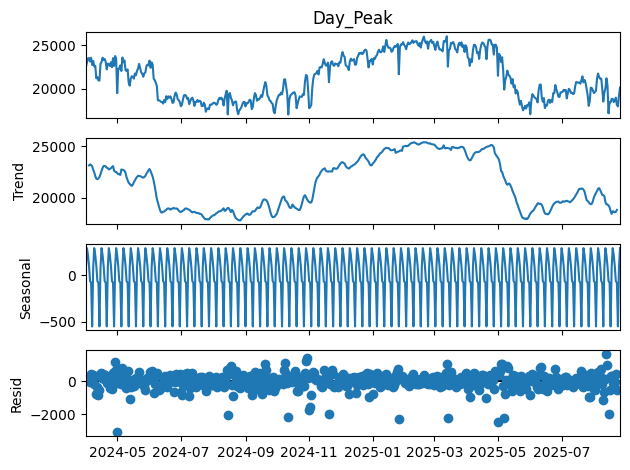

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
train_df['Date'] = pd.to_datetime(train_df['Date'])
ts = train_df.set_index('Date')['Day_Peak']

result = seasonal_decompose(ts, model='additive', period=7)

plt.figure(figsize=(50, 30))
result.plot()
plt.show()

<Figure size 10000x4000 with 0 Axes>

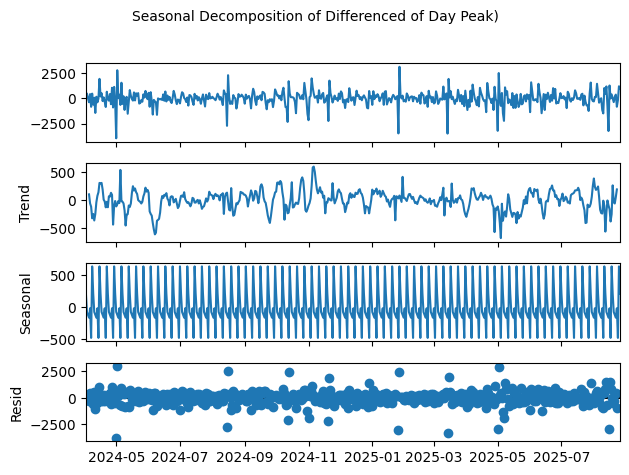

In [10]:


# --- use the exact column names from your train_df ---
date_col = 'Date'          # your exact date column
target_col = 'Day_Peak'  # change if needed

# --- create a time-series WITHOUT modifying train_df ---
ts = pd.to_datetime(train_df[date_col])
y = train_df[target_col].copy()

# --- build a new temporary series ---
series = pd.Series(y.values, index=ts).sort_index()

# --- first difference ---
diff_series = series.diff().dropna()

# --- decomposition ---
result = seasonal_decompose(diff_series, model='additive', period=7)

# --- plot ---
plt.figure(figsize=(50, 20),dpi=200)
result.plot()
plt.suptitle("Seasonal Decomposition of Differenced of Day Peak)", fontsize=10)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


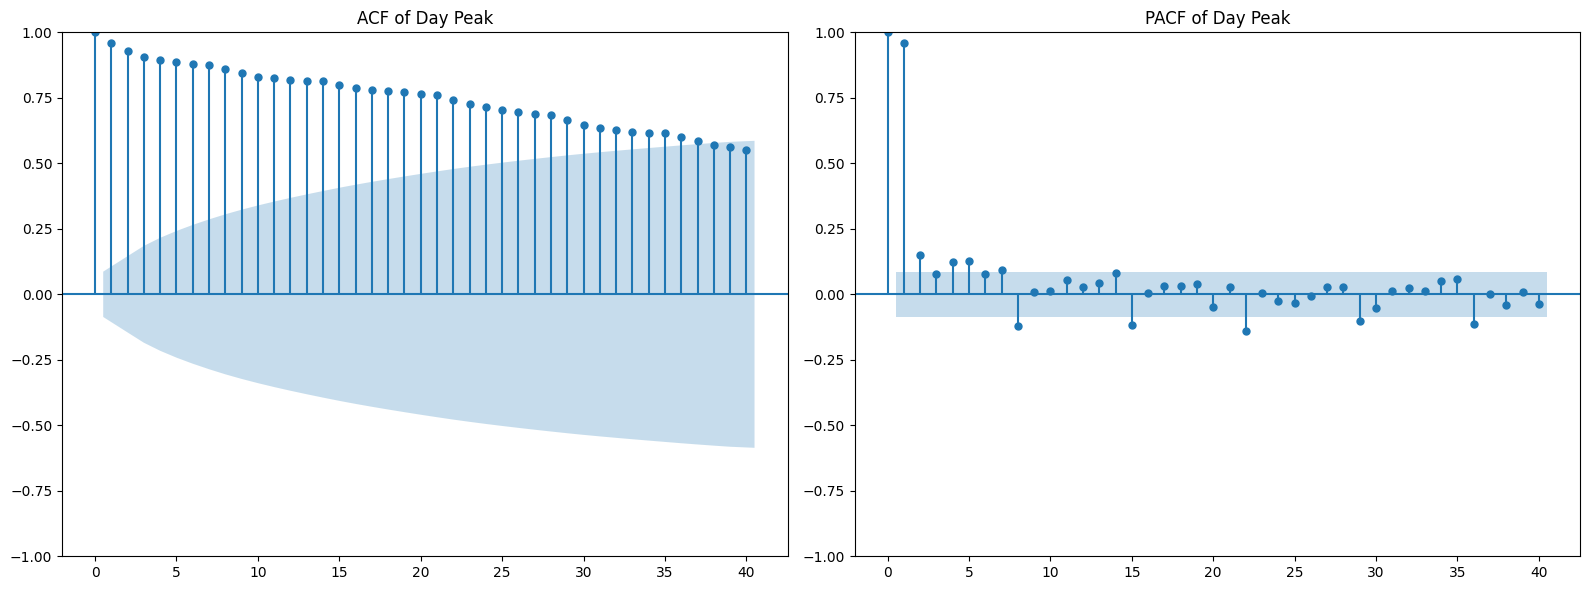

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ----- exact column names -----
date_col = 'Date'
target_col = 'Day_Peak'

# ----- create temporary time series -----
dates = pd.to_datetime(train_df[date_col])
y = train_df[target_col].copy()
series = pd.Series(y.values, index=dates).sort_index()

# ----- plot side-by-side -----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_acf(series, lags=40, ax=axes[0])
axes[0].set_title("ACF of Day Peak")

plot_pacf(series, lags=40, method='ywm', ax=axes[1])
axes[1].set_title("PACF of Day Peak")

plt.tight_layout()
plt.show()


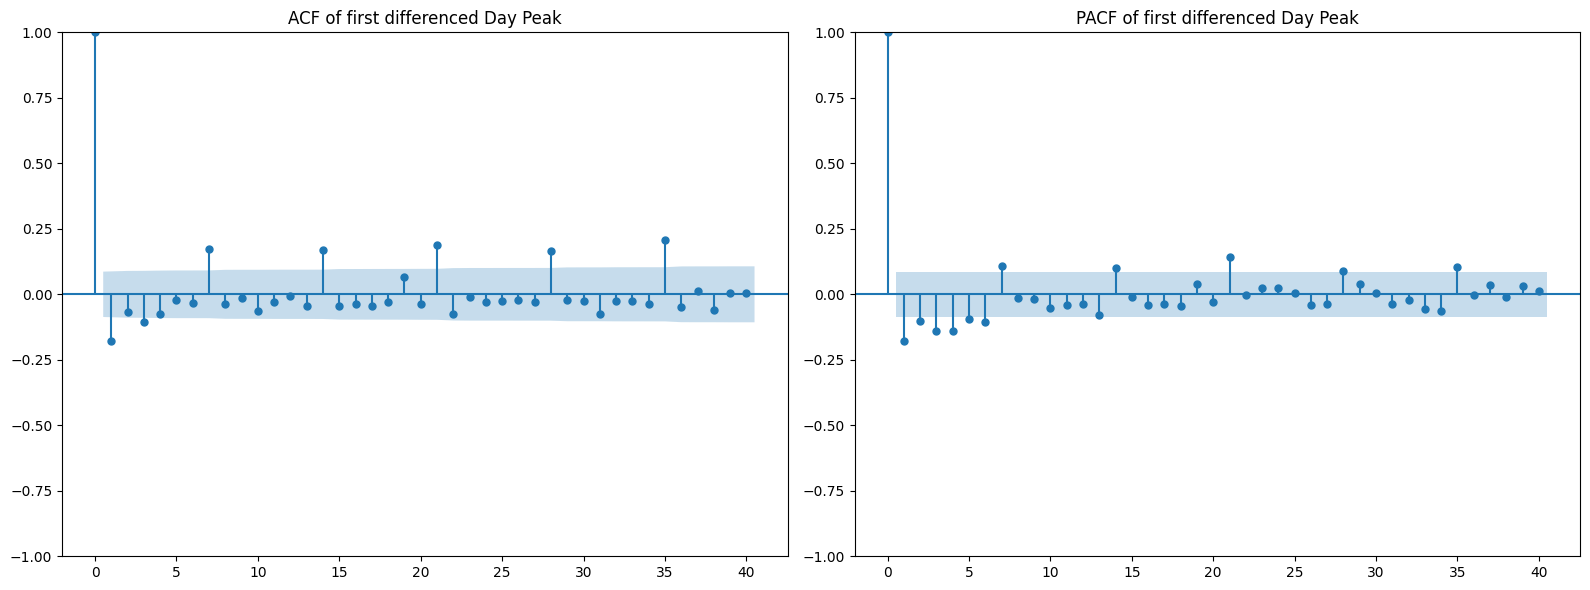

In [12]:
date_col = 'Date'
target_col = 'Day_Peak'

# ----- create temporary time series -----
dates = pd.to_datetime(train_df[date_col])
y = train_df[target_col].copy()
series = pd.Series(y.values, index=dates).sort_index()
diff_series = series.diff().dropna()

# ----- plot side-by-side -----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_acf(diff_series, lags=40, ax=axes[0])
axes[0].set_title("ACF of first differenced Day Peak")

plot_pacf(diff_series, lags=40, method='ywm', ax=axes[1])
axes[1].set_title("PACF of first differenced Day Peak")

plt.tight_layout()
plt.show()


In [13]:
from statsmodels.tsa.stattools import adfuller



# Run ADF
adf_res = adfuller(series.dropna(), autolag='AIC')  # dropna to be safe

adf_stat = adf_res[0]
p_value = adf_res[1]
used_lag = adf_res[2]
nobs = adf_res[3]
crit_values = adf_res[4]
icbest = adf_res[5]

# Print results
print("Augmented Dickey-Fuller test")
print("----------------------------")
print(f"ADF Statistic : {adf_stat:.6f}")
print(f"p-value       : {p_value:.6e}")
print(f"Used lag      : {used_lag}")
print(f"Number obs    : {nobs}")
print(f"IC best       : {icbest}")
print("Critical values:")
for k, v in crit_values.items():
    print(f"    {k} : {v:.6f}")

# Interpretation summary (alpha 0.05 and 0.01)
alpha = 0.05
alpha_strong = 0.01

if p_value < alpha:
    conclusion = f"Reject the null at alpha={alpha}. Series appears stationary (unit root NOT present)."
else:
    conclusion = f"Fail to reject the null at alpha={alpha}. Series appears non-stationary (unit root present)."

if p_value < alpha_strong:
    strong = f"Also reject at alpha={alpha_strong} (strong evidence of stationarity)."
else:
    strong = f"Do NOT reject at alpha={alpha_strong}."

print("\nConclusion:")
print(conclusion)
print(strong)

# Quick next-steps suggestions
if p_value >= alpha:
    print("\nSuggested fixes if non-stationary:")
    print("- Try differencing once: series.diff().dropna() and re-run ADF.")
    print("- Consider log transform: np.log(series.replace(0, np.nan)).dropna() (avoid zeros).")
    print("- Check and remove deterministic trend (use regression='ct' in adfuller to test with trend).")
else:
    print("\nIf stationary:")
    print("- You can proceed to identify AR/MA orders using ACF/PACF or fit ARIMA directly.")


Augmented Dickey-Fuller test
----------------------------
ADF Statistic : -1.727630
p-value       : 4.169361e-01
Used lag      : 7
Number obs    : 505
IC best       : 7876.383696001556
Critical values:
    1% : -3.443366
    5% : -2.867280
    10% : -2.569827

Conclusion:
Fail to reject the null at alpha=0.05. Series appears non-stationary (unit root present).
Do NOT reject at alpha=0.01.

Suggested fixes if non-stationary:
- Try differencing once: series.diff().dropna() and re-run ADF.
- Consider log transform: np.log(series.replace(0, np.nan)).dropna() (avoid zeros).
- Check and remove deterministic trend (use regression='ct' in adfuller to test with trend).


In [14]:


# Run ADF
adf_res = adfuller(diff_series.dropna(), autolag='AIC')  # dropna to be safe

adf_stat = adf_res[0]
p_value = adf_res[1]
used_lag = adf_res[2]
nobs = adf_res[3]
crit_values = adf_res[4]
icbest = adf_res[5]

# Print results
print("Augmented Dickey-Fuller test")
print("----------------------------")
print(f"ADF Statistic : {adf_stat:.6f}")
print(f"p-value       : {p_value:.6e}")
print(f"Used lag      : {used_lag}")
print(f"Number obs    : {nobs}")
print(f"IC best       : {icbest}")
print("Critical values:")
for k, v in crit_values.items():
    print(f"    {k} : {v:.6f}")

# Interpretation summary (alpha 0.05 and 0.01)
alpha = 0.05
alpha_strong = 0.01

if p_value < alpha:
    conclusion = f"Reject the null at alpha={alpha}. Series appears stationary (unit root NOT present)."
else:
    conclusion = f"Fail to reject the null at alpha={alpha}. Series appears non-stationary (unit root present)."

if p_value < alpha_strong:
    strong = f"Also reject at alpha={alpha_strong} (strong evidence of stationarity)."
else:
    strong = f"Do NOT reject at alpha={alpha_strong}."

print("\nConclusion:")
print(conclusion)
print(strong)

# Quick next-steps suggestions
if p_value >= alpha:
    print("\nSuggested fixes if non-stationary:")
    print("- Try differencing once: series.diff().dropna() and re-run ADF.")
    print("- Consider log transform: np.log(series.replace(0, np.nan)).dropna() (avoid zeros).")
    print("- Check and remove deterministic trend (use regression='ct' in adfuller to test with trend).")
else:
    print("\nIf stationary:")
    print("- You can proceed to identify AR/MA orders using ACF/PACF or fit ARIMA directly.")


Augmented Dickey-Fuller test
----------------------------
ADF Statistic : -10.129043
p-value       : 9.019510e-18
Used lag      : 6
Number obs    : 505
IC best       : 7861.251590015183
Critical values:
    1% : -3.443366
    5% : -2.867280
    10% : -2.569827

Conclusion:
Reject the null at alpha=0.05. Series appears stationary (unit root NOT present).
Also reject at alpha=0.01 (strong evidence of stationarity).

If stationary:
- You can proceed to identify AR/MA orders using ACF/PACF or fit ARIMA directly.


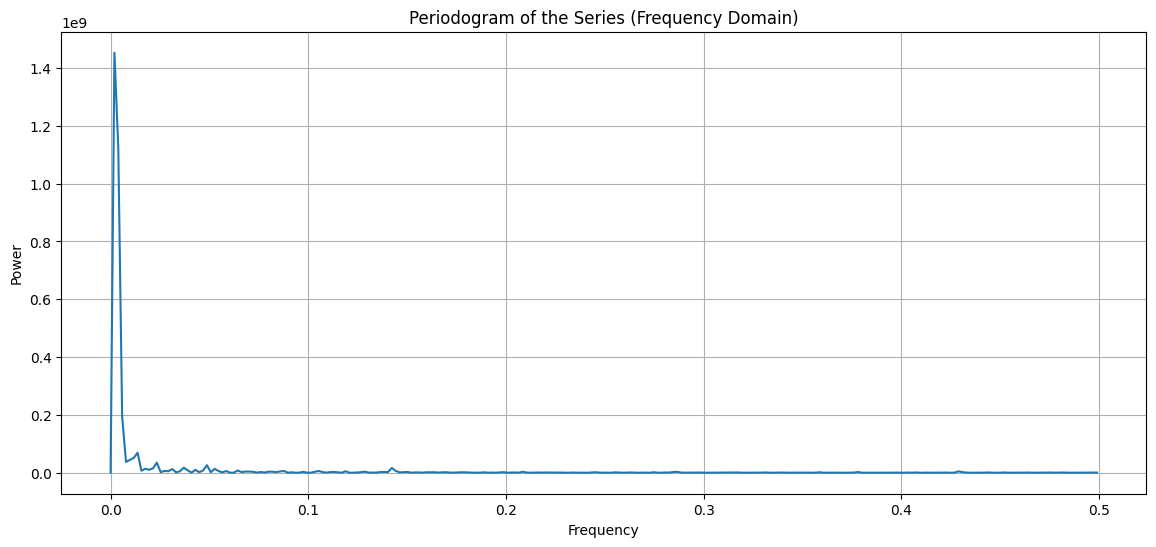

In [15]:
from scipy.signal import periodogram
import numpy as np
import matplotlib.pyplot as plt

# assume 'series' already exists and is a numeric pd.Series with datetime index
y = series.dropna().values

# Compute periodogram
freqs, power = periodogram(y)

# Plot
plt.figure(figsize=(14, 6))
plt.plot(freqs, power)
plt.title("Periodogram of the Series (Frequency Domain)")
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.grid(True)
plt.show()


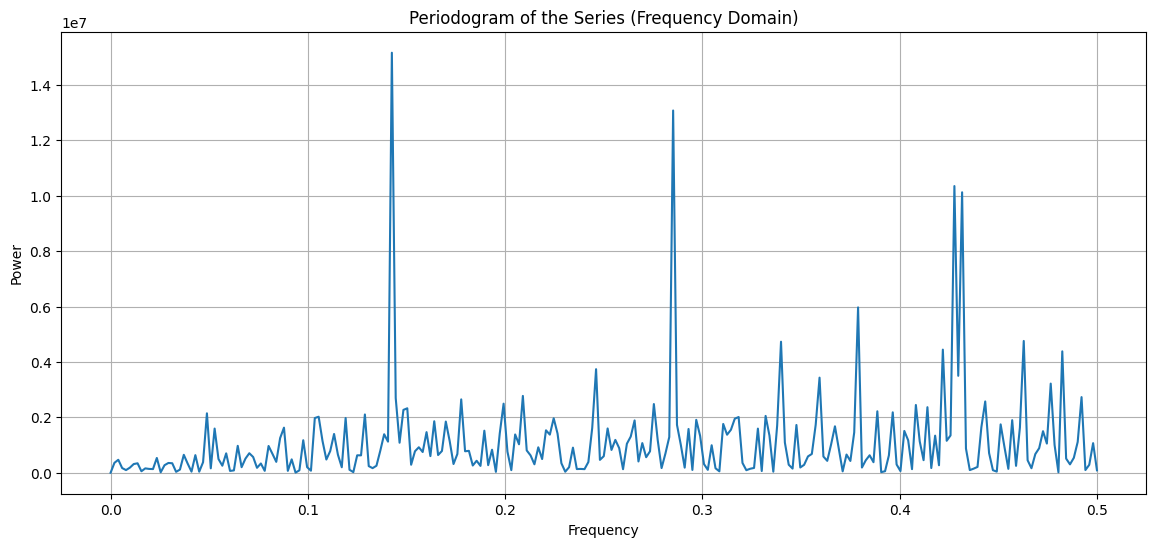

In [16]:
from scipy.signal import periodogram
import numpy as np
import matplotlib.pyplot as plt

# assume 'series' already exists and is a numeric pd.Series with datetime index
y = diff_series.dropna().values

# Compute periodogram
freqs, power = periodogram(y)

# Plot
plt.figure(figsize=(14, 6))
plt.plot(freqs, power)
plt.title("Periodogram of the Series (Frequency Domain)")
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.grid(True)
plt.show()


Top spectral peaks (sorted by power):
   frequency    period         power
0   0.142578  7.013699  1.516347e+07
1   0.285156  3.506849  1.307733e+07
2   0.427734  2.337900  1.034954e+07
3   0.431641  2.316742  1.012439e+07
4   0.378906  2.639175  5.968876e+06
5   0.462891  2.160338  4.756946e+06
6   0.339844  2.942529  4.729986e+06
7   0.421875  2.370370  4.443954e+06
8   0.482422  2.072874  4.382255e+06
9   0.246094  4.063492  3.738005e+06


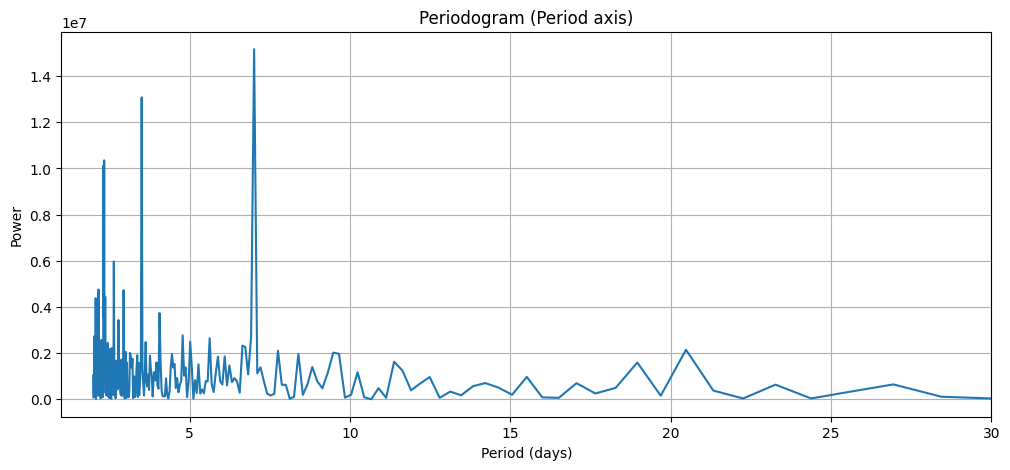

In [17]:
import numpy as np
from scipy.signal import periodogram, find_peaks
import pandas as pd

y = diff_series.dropna().values  # your differenced series (numpy array)
fs = 1.0  # sampling rate = 1 sample per day (adjust if different)
freqs, power = periodogram(y, fs=fs)

# ignore the zero-frequency bin
freqs_nz = freqs[1:]
power_nz = power[1:]

# find peaks in the power spectrum
peaks, _ = find_peaks(power_nz, height=np.max(power_nz)*0.05)  # peaks above 5% of max
peak_freqs = freqs_nz[peaks]
peak_power = power_nz[peaks]
periods = 1 / peak_freqs

# create tidy table
df_peaks = pd.DataFrame({
    "frequency": peak_freqs,
    "period": periods,
    "power": peak_power
}).sort_values("power", ascending=False).reset_index(drop=True)

print("Top spectral peaks (sorted by power):")
print(df_peaks.head(10))

# optional: plot power vs period (more readable)
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(1/freqs_nz, power_nz)        # period vs power
plt.xlim(1, 30)                       # show periods from 1 to 30 days
plt.xlabel("Period (days)")
plt.ylabel("Power")
plt.title("Periodogram (Period axis)")
plt.grid(True)
plt.show()


In [18]:
# install pmdarima if needed
# pip install pmdarima

from pmdarima.arima.utils import nsdiffs

# nsdiffs returns the recommended seasonal differencing order D
# test='ch' => Canova-Hansen, test='ocsb' => OCSB test
s = 7
D_ch = nsdiffs(series.values, m=s, test='ch', max_D=2)     # Canova-Hansen
D_ocsb = nsdiffs(series.values, m=s, test='ocsb', max_D=2) # OCSB

print("Canova-Hansen recommended D:", D_ch)
print("OCSB recommended D:", D_ocsb)


Canova-Hansen recommended D: 0
OCSB recommended D: 0


ADF result for series after d=1 and D=1
ADF Statistic: -10.005224
p-value      : 0.000000
Used lags    : 16
N obs        : 488
Critical values:
   1%: -3.443821
   5%: -2.867481
   10%: -2.569934


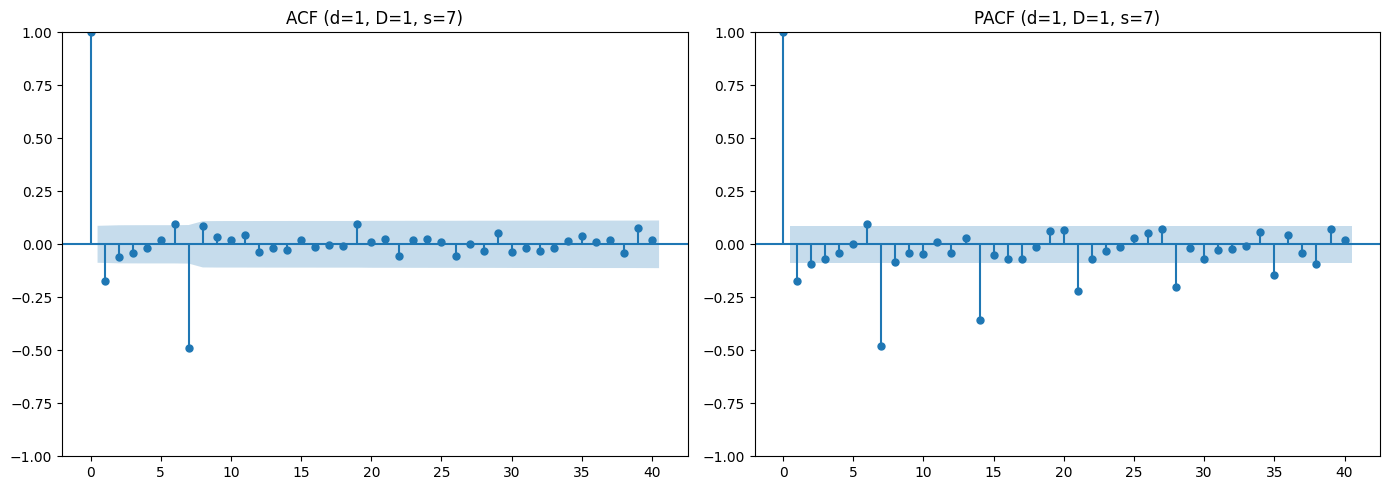

In [19]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# seasonal period
s = 7

# prepare series: first diff (d=1) then seasonal diff (D=1)
d1 = series.diff().dropna()
d1D1 = d1.diff(s).dropna()

# ADF on d=1, D=1
adf_res = adfuller(d1D1, autolag='AIC')
print("ADF result for series after d=1 and D=1")
print(f"ADF Statistic: {adf_res[0]:.6f}")
print(f"p-value      : {adf_res[1]:.6f}")
print(f"Used lags    : {adf_res[2]}")
print(f"N obs        : {adf_res[3]}")
print("Critical values:")
for k, v in adf_res[4].items():
    print(f"   {k}: {v:.6f}")

# Side-by-side ACF & PACF for d=1,D=1 only
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(d1D1, lags=40, ax=axes[0])
axes[0].set_title(f"ACF (d=1, D=1, s={s})")

plot_pacf(d1D1, lags=40, ax=axes[1], method='ywm')
axes[1].set_title(f"PACF (d=1, D=1, s={s})")

plt.tight_layout()
plt.show()


ADF result for series after d=1 and D=0
ADF Statistic: -10.129043
p-value      : 0.000000
Used lags    : 6
N obs        : 505
Critical values:
   1%: -3.443366
   5%: -2.867280
   10%: -2.569827


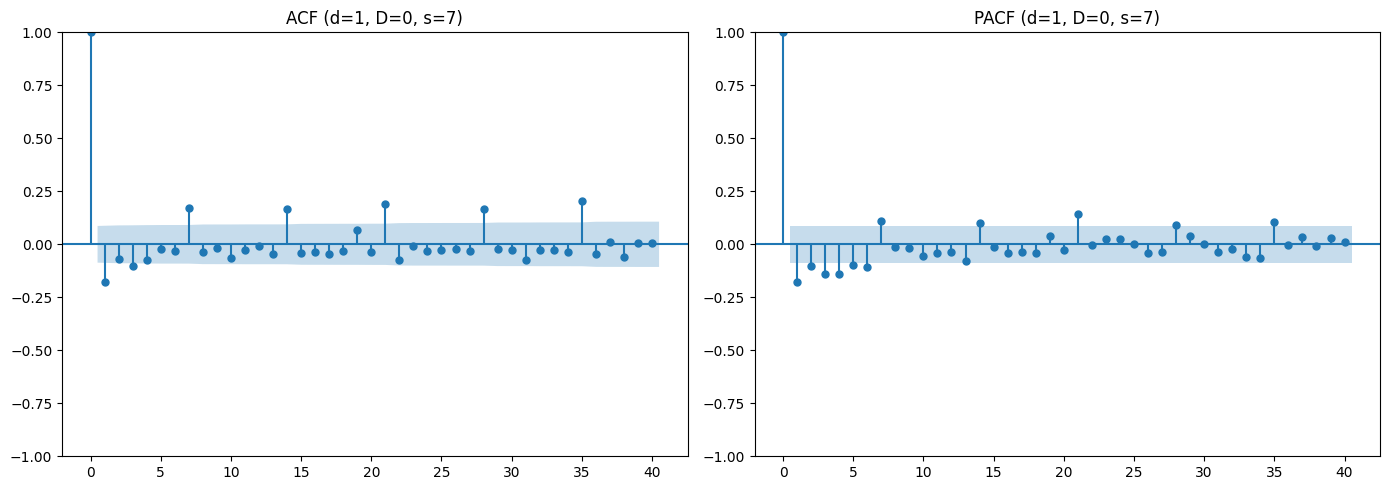

In [20]:

# seasonal period
s = 7

# prepare series: first diff (d=1)
d1 = series.diff().dropna()
adf_res = adfuller(d1, autolag='AIC')
print("ADF result for series after d=1 and D=0")
print(f"ADF Statistic: {adf_res[0]:.6f}")
print(f"p-value      : {adf_res[1]:.6f}")
print(f"Used lags    : {adf_res[2]}")
print(f"N obs        : {adf_res[3]}")
print("Critical values:")
for k, v in adf_res[4].items():
    print(f"   {k}: {v:.6f}")

# Side-by-side ACF & PACF for d=1,D=0 only
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(d1, lags=40, ax=axes[0])
axes[0].set_title(f"ACF (d=1, D=0, s={s})")

plot_pacf(d1, lags=40, ax=axes[1], method='ywm')
axes[1].set_title(f"PACF (d=1, D=0, s={s})")

plt.tight_layout()
plt.show()


In [21]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_error, mean_squared_error

def sarima_pipeline_fixed_orders(
    train,
    test,
    order,               # <-- MUST BE PROVIDED (p,d,q)
    seasonal_order,      # <-- MUST BE PROVIDED (P,D,Q,m)
    date_col='Date',
    target_col='Day_Peak',
    enforce_stationary=True,
    enforce_invertible=True,
    alpha=0.05,
    lb_max_lag=24,       # number of lags to compute/plot for Ljung-Box
    verbose=True
):
    """
    Fit SARIMA with user-provided orders and evaluate.
    Returns diagnostics, metrics (including R^2), forecasts and Ljung-Box results and plots them.
    """

    # --- prepare series ---
    def _prepare(df):
        dfc = df.copy()
        dfc[date_col] = pd.to_datetime(dfc[date_col])
        dfc = dfc.set_index(date_col).sort_index()
        return dfc[target_col].astype(float)

    y_train = _prepare(train)
    y_test = _prepare(test)

    if verbose:
        print(f"Fitting SARIMAX with order={order} seasonal_order={seasonal_order} ...")

    # --- fit model ---
    model = SARIMAX(
        y_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationary=enforce_stationary,
        enforce_invertible=enforce_invertible
    )

    fit = model.fit(disp=False, method='lbfgs', maxiter=200)

    # --- summary ---
    if verbose:
        print("\n=== Model Summary ===")
        print(fit.summary())

    # --- coefficients ---
    coef_table = pd.DataFrame({
        'coef': fit.params,
        'std_err': fit.bse,
        'pvalue': fit.pvalues
    })

    if verbose:
        print("\n=== Coefficient Table ===")
        print(coef_table)

    # --- forecast ---
    n_steps = len(y_test)
    fc_res = fit.get_forecast(steps=n_steps)
    forecast = pd.Series(fc_res.predicted_mean, index=y_test.index)
    conf_int = fc_res.conf_int(alpha=alpha)
    conf_int.index = y_test.index

    # --- metrics ---
    y_test_arr = np.asarray(y_test)
    forecast_arr = np.asarray(forecast)

    mae = mean_absolute_error(y_test_arr, forecast_arr)
    mse = mean_squared_error(y_test_arr, forecast_arr)
    rmse = np.sqrt(mse)

    denom = np.where(y_test_arr == 0, np.nan, y_test_arr)
    with np.errstate(divide='ignore', invalid='ignore'):
        mape_vals = np.abs((y_test_arr - forecast_arr) / denom)
    mape = np.nan if np.all(np.isnan(mape_vals)) else np.nanmean(mape_vals) * 100.0


    metrics = {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE(%)": mape,
        "AIC": fit.aic,
        "BIC": fit.bic
    }

    if verbose:
        print("\n=== Metrics ===")
        for k, v in metrics.items():
            print(f"{k}: {v}")

    # --- Residuals ---
    resid = fit.resid.dropna()

    # --- Ljung-Box: run for lags 1..lb_max_lag ---
    lb_lags = list(range(1, lb_max_lag + 1))
    lb = acorr_ljungbox(resid, lags=lb_lags, return_df=True)
    if verbose:
        print("\n=== Ljung-Box (first rows) ===")
        print(lb.head())

    # --- Plot residual diagnostics (residuals, hist, QQ, resid ACF) ---
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(3, 2)
    ax0 = fig.add_subplot(gs[0, :])
    ax1 = fig.add_subplot(gs[1, 0])
    ax2 = fig.add_subplot(gs[1, 1])
    ax3 = fig.add_subplot(gs[2, :])

    ax0.plot(resid.index, resid, label='resid')
    ax0.axhline(0, color='k', linewidth=0.8)
    ax0.set_title('Model residuals (train)')
    ax0.legend()

    ax1.hist(resid, bins=30)
    ax1.set_title('Residual histogram')

    try:
        import statsmodels.api as sm
        sm.qqplot(resid, line='s', ax=ax2)
        ax2.set_title('QQ-plot of residuals')
    except Exception:
        ax2.text(0.1, 0.5, 'statsmodels not available for QQ-plot', transform=ax2.transAxes)

    plot_acf(resid, lags=40, ax=ax3)
    ax3.set_title('Residual ACF (train)')

    plt.tight_layout()
    plt.show()

    # --- Plot Ljung-Box p-values and stats ---
    fig, ax1 = plt.subplots(figsize=(12,4))
    ax1.plot(lb.index, lb['lb_pvalue'], marker='o', linestyle='-', label='Ljung-Box p-value')
    ax1.axhline(0.05, color='red', linestyle='--', label='alpha=0.05')
    ax1.set_xlabel('Lag')
    ax1.set_ylabel('p-value')
    ax1.set_ylim(bottom=0, top=1.05)
    ax1.set_title('Ljung-Box p-values by lag (residuals)')
    ax1.grid(True)
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    stat_col = 'lb_stat' if 'lb_stat' in lb.columns else lb.columns[0]
    ax2.plot(lb.index, lb[stat_col], color='grey', alpha=0.6, marker='x', label='Ljung-Box stat')
    ax2.set_ylabel('LB statistic')
    ax2.legend(loc='upper right')
    plt.show()

    # --- Forecast vs Actual (Train+Test) ---
    plt.figure(figsize=(14,6))
    plt.plot(y_train, label="Train")
    plt.plot(y_test, label="Actual Test")
    plt.plot(forecast, label="Forecast")
    plt.fill_between(forecast.index, conf_int.iloc[:,0], conf_int.iloc[:,1],
                     alpha=0.3, color="pink")
    plt.legend()
    plt.title("Forecast vs Actual (Train + Test)")
    plt.show()

    # --- Forecast vs Actual (Test Only) ---
    plt.figure(figsize=(10,5))
    plt.plot(y_test, label="Actual Test", marker='o')
    plt.plot(forecast, label="Forecast", marker='x')
    plt.fill_between(forecast.index, conf_int.iloc[:,0], conf_int.iloc[:,1],
                     alpha=0.3, color="pink")
    plt.legend()
    plt.title("Forecast vs Actual (Test Only)")
    plt.show()

    # --- assemble output ---
    out = {
        "model": fit,
        "coef_table": coef_table,
        "forecast": forecast,
        "forecast_conf_int": conf_int,
        "metrics": metrics,
        "residuals": resid,
        "ljung_box": lb
    }

    return out


Fitting SARIMAX with order=(1, 1, 1) seasonal_order=(1, 0, 1, 7) ...

=== Model Summary ===
                                     SARIMAX Results                                     
Dep. Variable:                          Day_Peak   No. Observations:                  513
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 7)   Log Likelihood               -4055.176
Date:                           Sun, 07 Dec 2025   AIC                           8120.353
Time:                                   10:16:48   BIC                           8141.544
Sample:                               04-01-2024   HQIC                          8128.660
                                    - 08-26-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6457      0.0

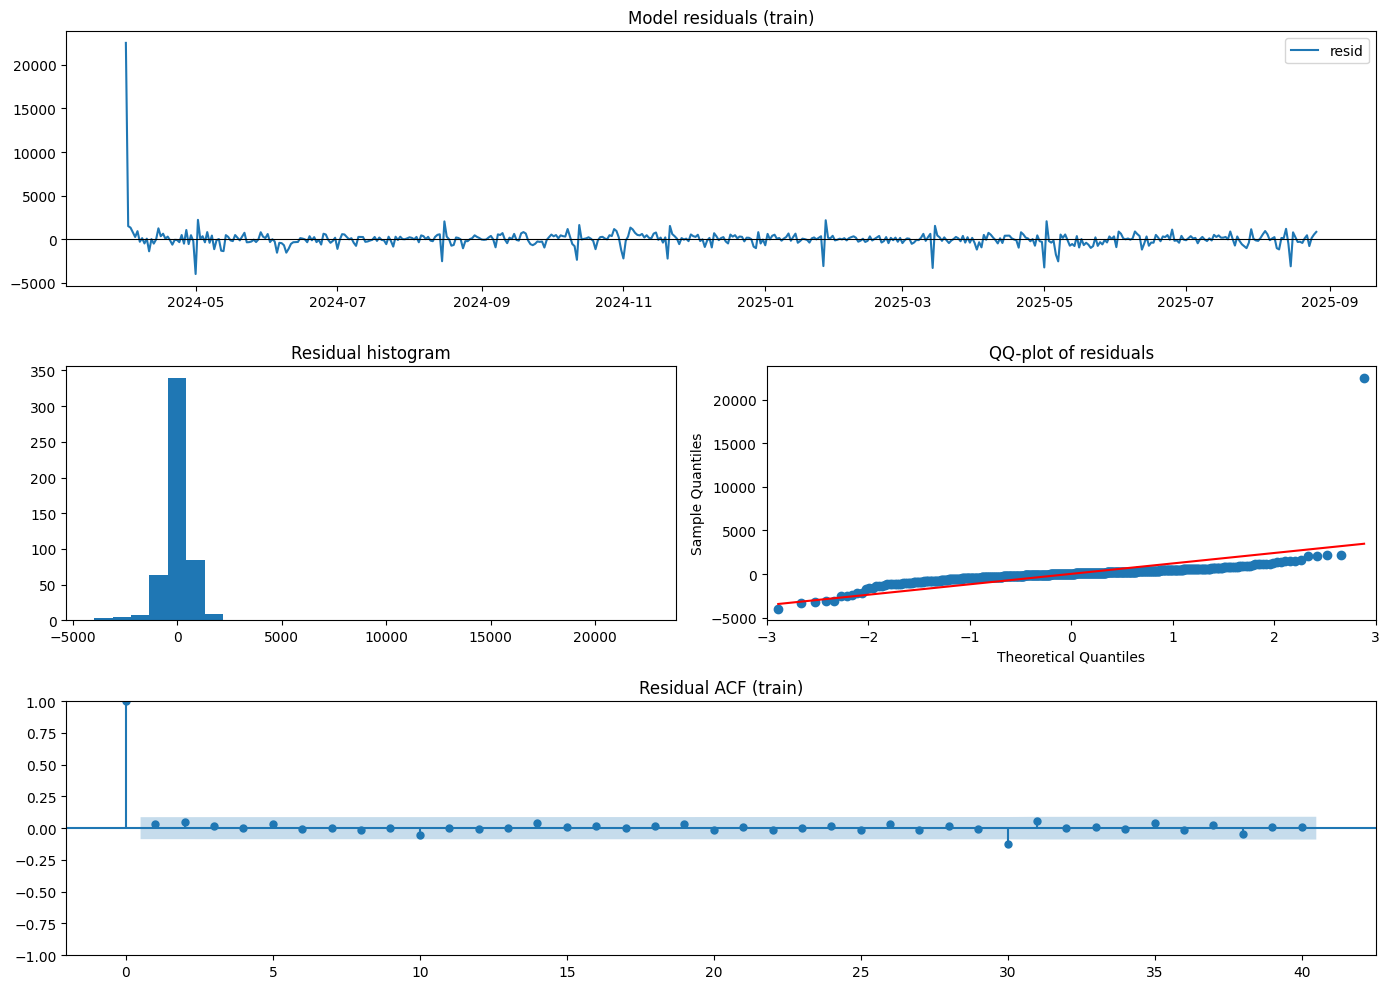

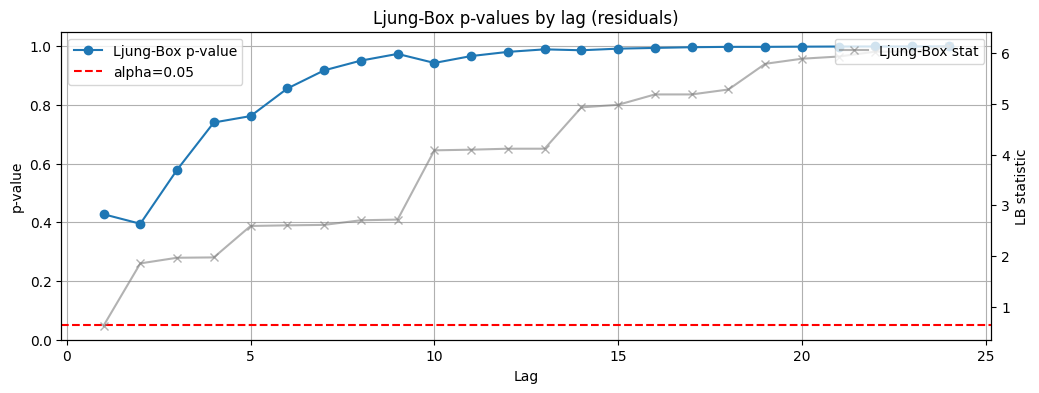

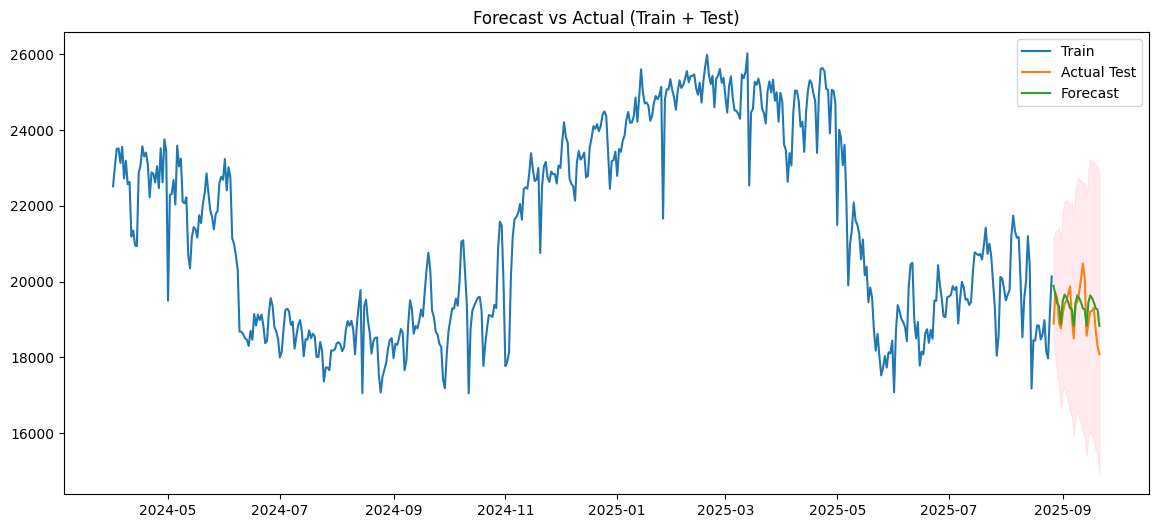

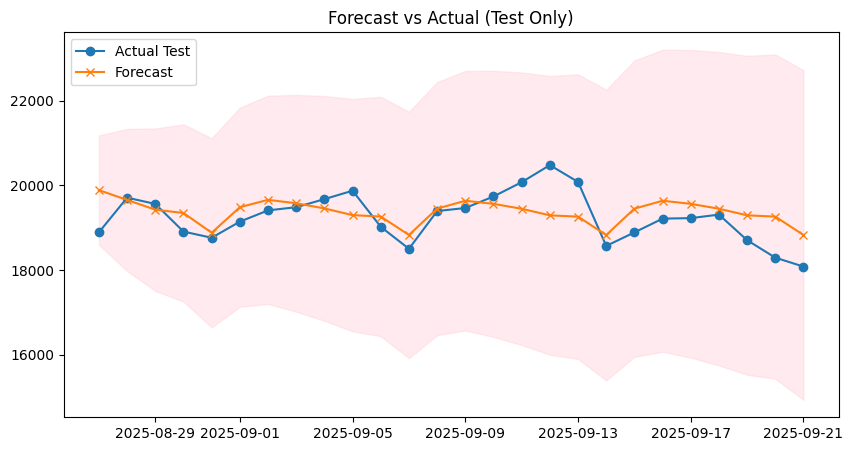

In [22]:
res = sarima_pipeline_fixed_orders(
    train_df,
    test_df,
    date_col='Date',
    target_col='Day_Peak',
    order=(1,1,1),
    seasonal_order=(1,0,1,7),
    verbose=True
)

Fitting SARIMAX with order=(0, 1, 1) seasonal_order=(1, 0, 1, 7) ...

=== Model Summary ===
                                     SARIMAX Results                                     
Dep. Variable:                          Day_Peak   No. Observations:                  513
Model:             SARIMAX(0, 1, 1)x(1, 0, 1, 7)   Log Likelihood               -4061.575
Date:                           Sun, 07 Dec 2025   AIC                           8131.150
Time:                                   10:16:51   BIC                           8148.103
Sample:                               04-01-2024   HQIC                          8137.796
                                    - 08-26-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.1596      0.0

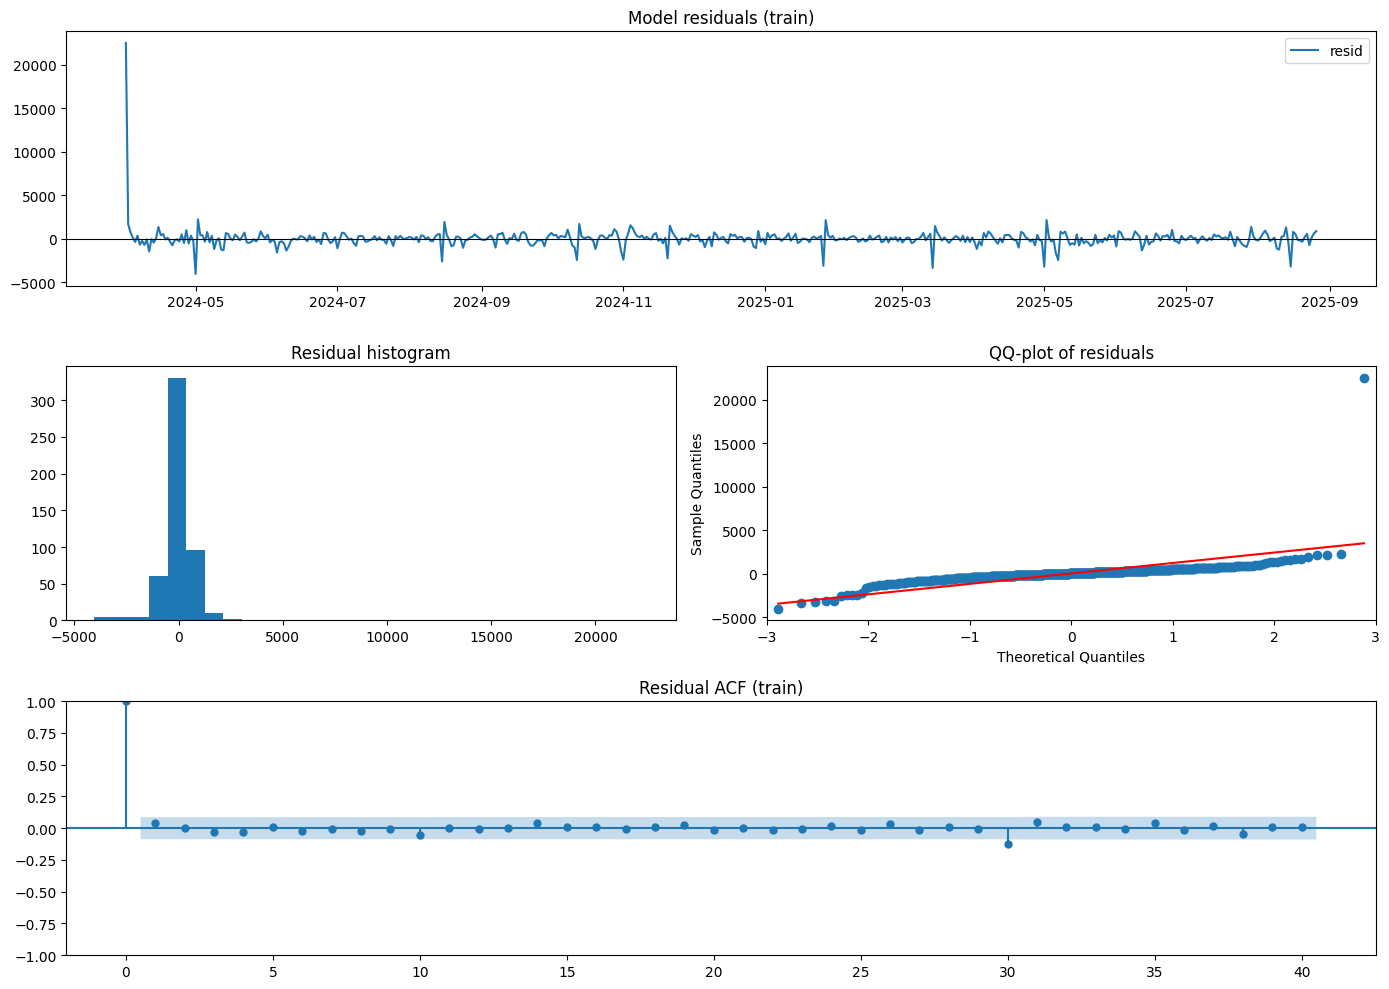

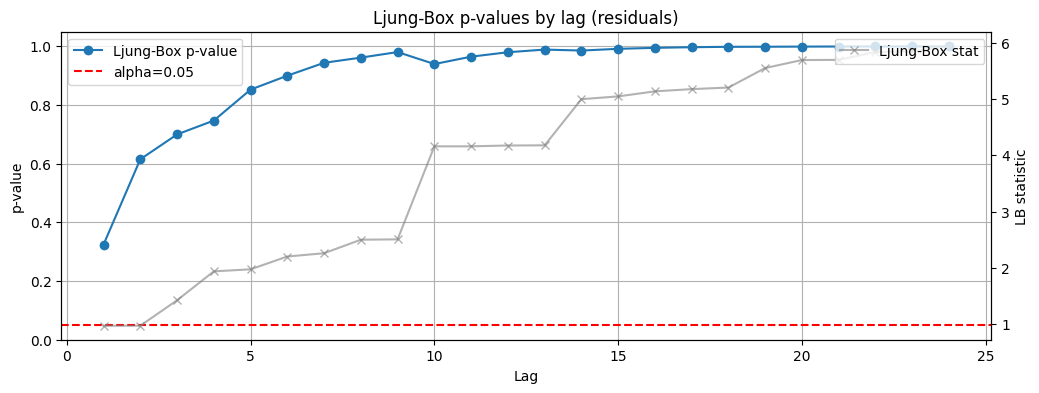

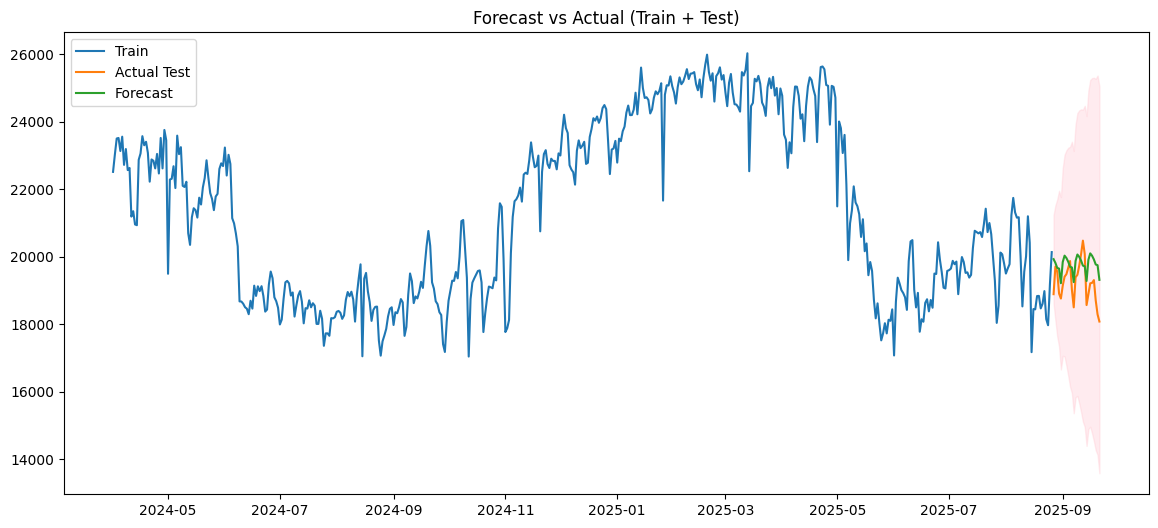

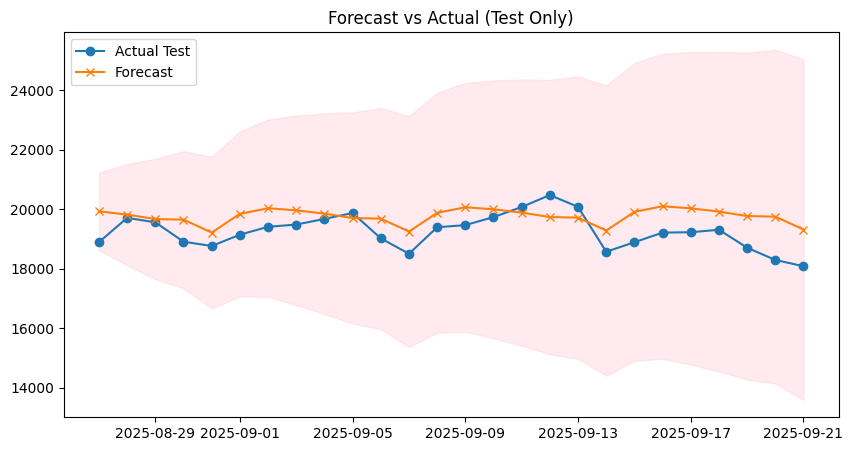

In [23]:
res = sarima_pipeline_fixed_orders(
    train_df,
    test_df,
    date_col='Date',
    target_col='Day_Peak',
    order=(0,1,1),
    seasonal_order=(1,0,1,7),
    verbose=True
)

Fitting SARIMAX with order=(1, 1, 0) seasonal_order=(1, 0, 1, 7) ...

=== Model Summary ===
                                      SARIMAX Results                                      
Dep. Variable:                            Day_Peak   No. Observations:                  513
Model:             SARIMAX(1, 1, 0)x(1, 0, [1], 7)   Log Likelihood               -4062.408
Date:                             Sun, 07 Dec 2025   AIC                           8132.817
Time:                                     10:16:55   BIC                           8149.770
Sample:                                 04-01-2024   HQIC                          8139.462
                                      - 08-26-2025                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         

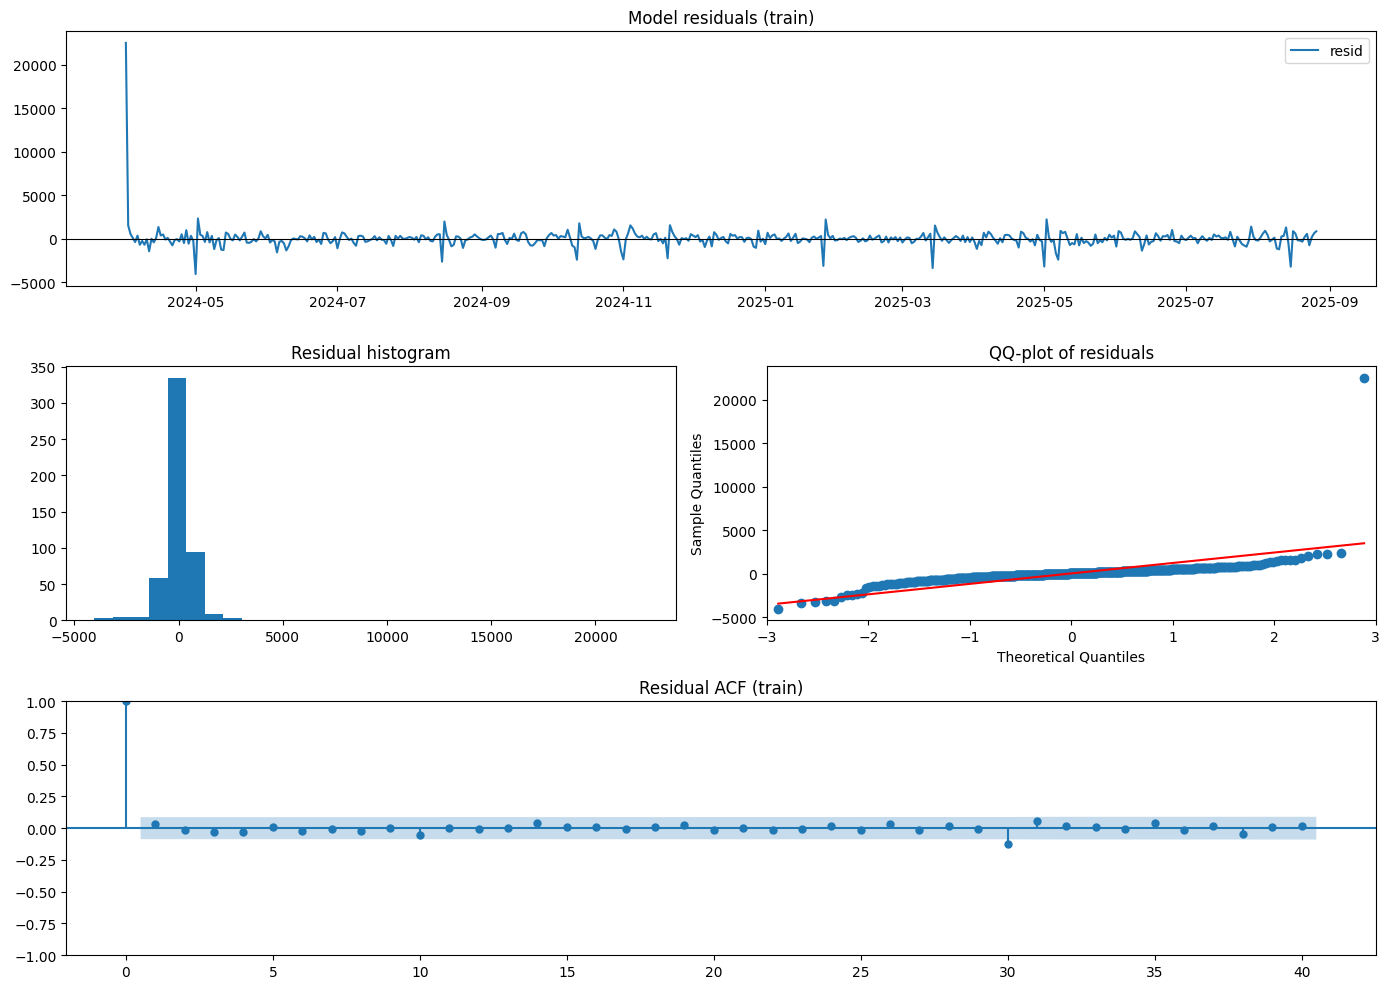

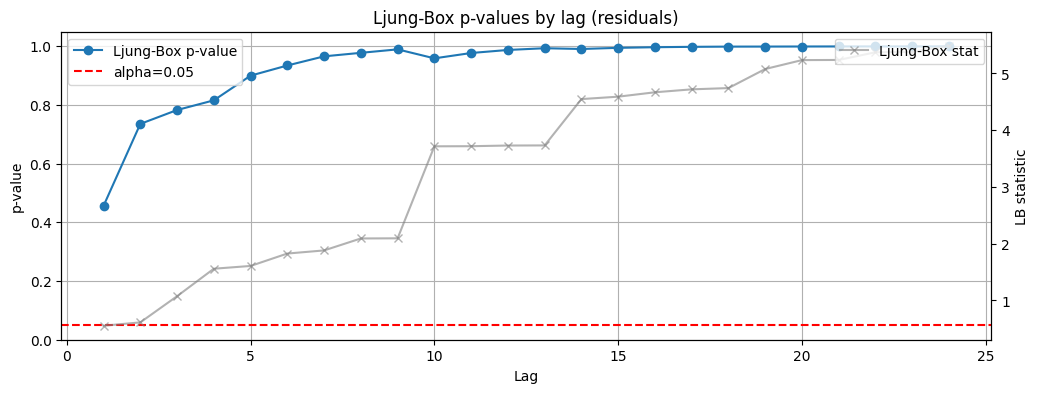

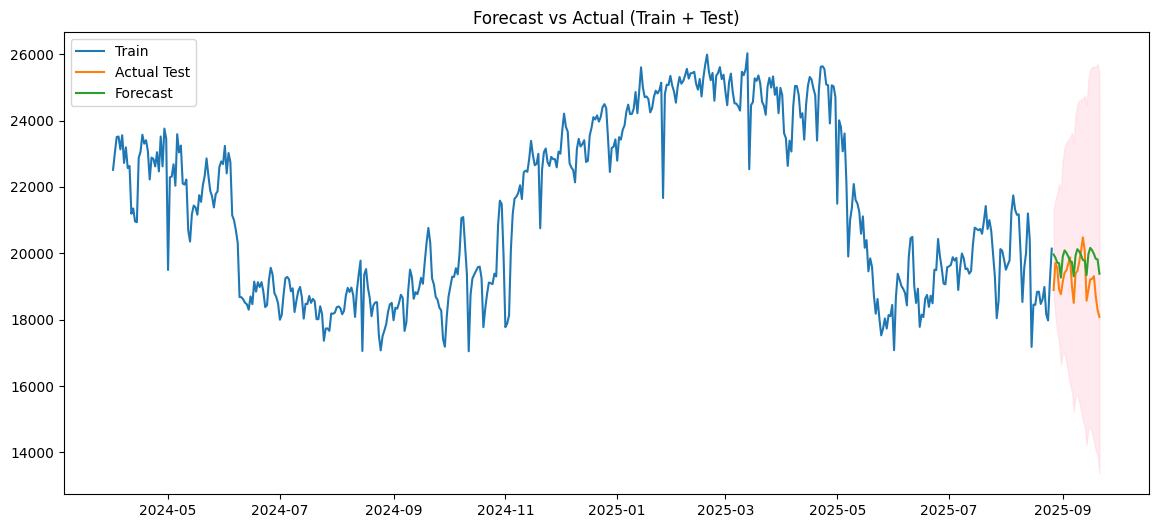

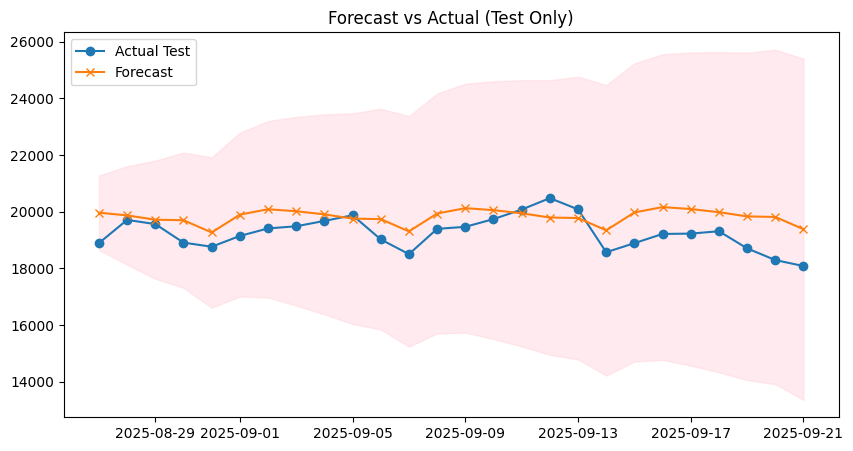

In [24]:
res = sarima_pipeline_fixed_orders(
    train_df,
    test_df,
    date_col='Date',
    target_col='Day_Peak',
    order=(1,1,0),
    seasonal_order=(1,0,1,7),
    verbose=True)

Fitting SARIMAX with order=(2, 1, 1) seasonal_order=(1, 0, 1, 7) ...

=== Model Summary ===
                                     SARIMAX Results                                     
Dep. Variable:                          Day_Peak   No. Observations:                  513
Model:             SARIMAX(2, 1, 1)x(1, 0, 1, 7)   Log Likelihood               -4057.114
Date:                           Sun, 07 Dec 2025   AIC                           8126.228
Time:                                   10:17:00   BIC                           8151.658
Sample:                               04-01-2024   HQIC                          8136.197
                                    - 08-26-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7153      0.1

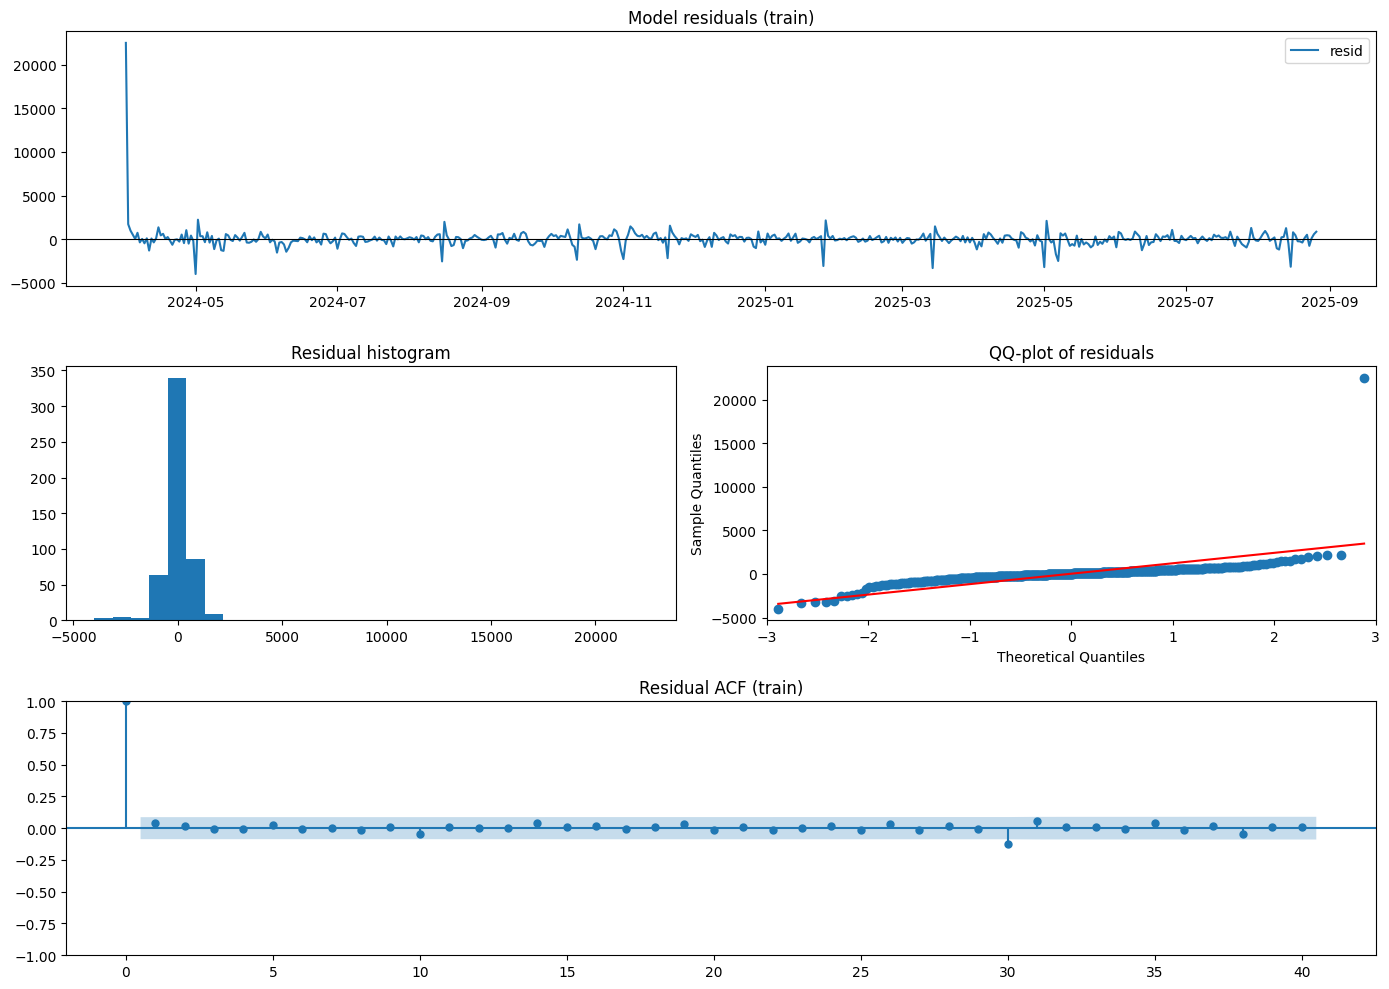

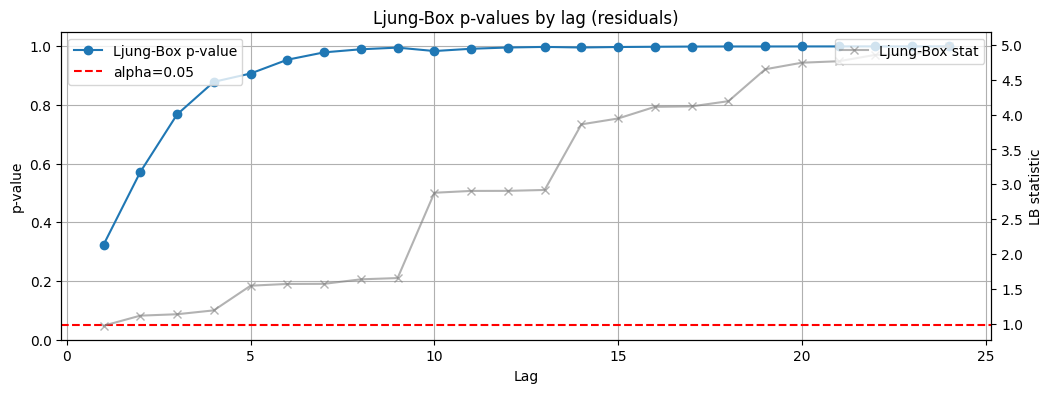

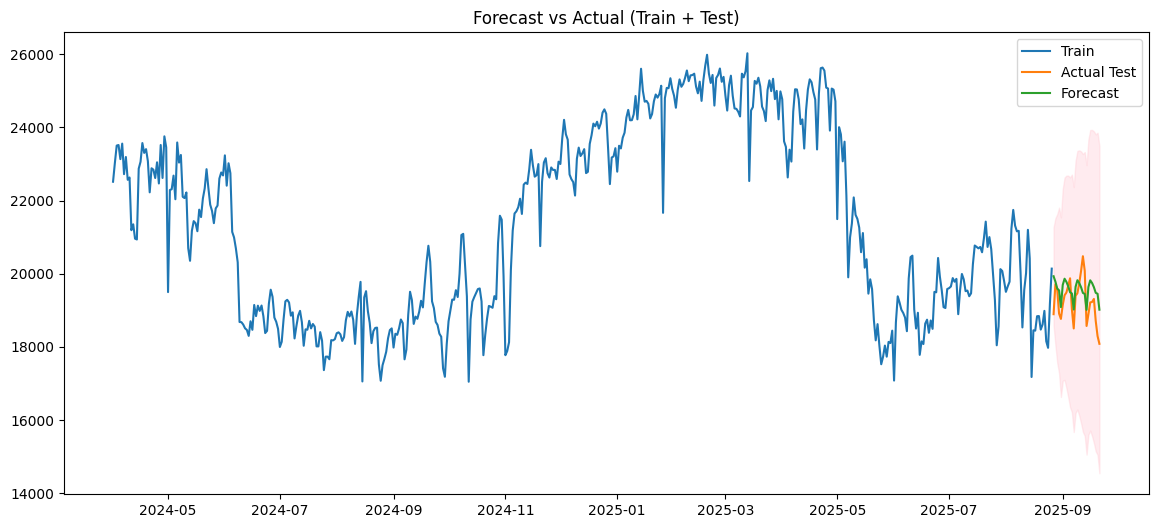

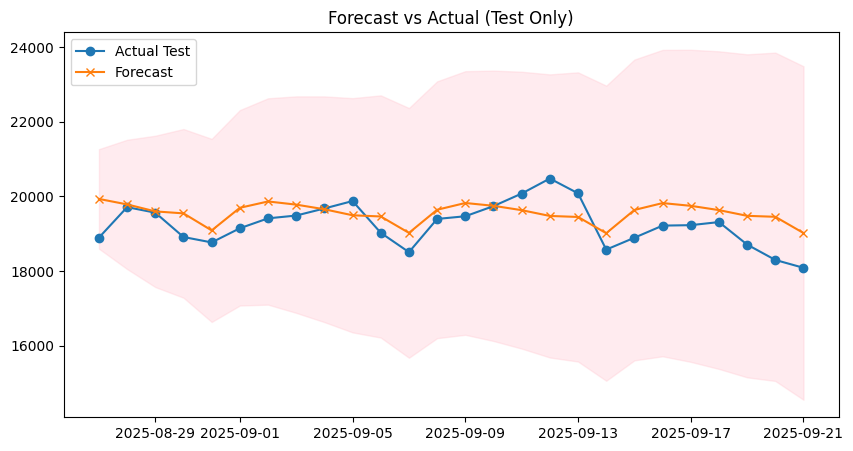

In [25]:
res = sarima_pipeline_fixed_orders(
    train_df,
    test_df,
    date_col='Date',
    target_col='Day_Peak',
    order=(2,1,1),
    seasonal_order=(1,0,1,7),
    verbose=True)